In [52]:
! pip install pingouin

In [53]:
import numpy as np
import pandas as pd
import statistics
from statsmodels import robust
from scipy import stats
from scipy.stats import t, sem, levene
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime, timedelta
import pingouin as pg
from pingouin import ttest
import itertools

In [ ]:

def asset_return(ticker_list): # function to get the asset return dataframe
    ticker_return = []
    for ticker in ticker_list.keys():
        ticker = yf.Ticker(ticker)
        ticker_df = ticker.history(period='max') # maximum amount of allowed historical data
        ticker_df['Return'] = ticker_df['Close'].pct_change().dropna(how='any')
        ticker_df.index = pd.Index(ticker_df.index.values.astype('M8[D]')) # make index yyyy-mm-dd
        ticker_return.append(ticker_df['Return'])
    
    ticker_return = pd.concat(ticker_return, axis=1).ffill().dropna(how='any')
    ticker_return.columns = ticker_list.values()
    ticker_return = ticker_return.iloc[:-1,:] # up to yesterday as today is not complete
    ticker_return[ticker_return<-1] = -0.50 # something is wrong with crude oil data, cannot have < -100% return
    
    return ticker_return

def asset_return_des_stats(ticker_df): # function to get the asset return descriptive statistics
    ticker_skewness = ticker_df.skew()
    ticker_kurtosis = stats.kurtosis(ticker_df, fisher=True)
    ticker_describe = ticker_df.describe()
    
    ticker_misc = pd.DataFrame([ticker_skewness, ticker_kurtosis], 
                               index=['skewness', 'kurtosis'],
                               columns=[ticker_df.name])    
    ticker_des_stats = pd.concat([ticker_describe.to_frame(), ticker_misc], axis=0)[ticker_df.name]
    
    return ticker_des_stats

def asset_return_stratified(ticker_df, ticker='SP500'):
# this function is for stratified sampling
## for the 10 samples, each samples starts from a calender year in which trading data is available
## i.e., 2014 - 2023, Oct 1 (e.g., datetime(2014, 10, 1))

    ns = 10 # number of samples
    
    sample_list = []
    for i in ticker_df.index.year.unique()[0:ns]:
        sample_period = pd.date_range(start=datetime(i,10,1), 
                                      #end=min(datetime.today().date()-timedelta(1),datetime(i+1,9,30).date()), 
                                      end=min(ticker_df.index[-1].date(),datetime(i+1,9,30).date()), 
                                      freq='D')
        sample = ticker_df.loc[sample_period,ticker].to_frame().rename(columns={ticker:str(i)}).reset_index(drop=True)
        sample_list.append(sample)
    sample_list = pd.concat(sample_list, axis=1)
    
    return sample_list    

def sample_des_stats(sample): # function to get the asset return descriptive statistics
    # samples are not of equal length, omit NAs
    sample_des = sample.describe()
    sample_skewness = sample.skew()
    sample_kurtosis = stats.kurtosis(sample, fisher=True, nan_policy='omit')     
    
    # standard error of mean (SEM)
    sample_std_error = sem(sample, nan_policy='omit')

    # confidence interval, upper and lower
    sample_ci = t.interval(confidence=.95, df=sample.notna().sum()-1,
                           loc=np.mean(sample), scale=sem(sample,nan_policy='omit'))   
    
    sample_misc = pd.DataFrame([sample_skewness, sample_kurtosis, sample_std_error, sample_ci[0], sample_ci[1]], 
                               index=['skewness','kurtosis','std_err_mean (sem)','ci_lower', 'ci_upper'],
                               columns=[sample.name])
    sample_des_stats = pd.concat([sample_des.to_frame(), sample_misc], axis=0)[sample.name]
    
    return sample_des_stats


def asset_1ttest(ticker_df, mu_0=0.0, alternative='two-sided', correction='False'):
    # default alternative is 'two-sided' tests, other alternatives are 'greater' and 'less'
    # default correction is 'False' for Student t test (equ sample size or std), 
    ## other correction is 'True' for Welch t test (different sample size or std)
    asset_ret_1ttest = ttest(ticker_df, mu_0, alternative=alternative, correction=correction).round(4).T.rename(columns={"T-test":ticker_df.name})
    ticker_misc = pd.DataFrame([mu_0, ticker_df.mean()], index=['mu_null', 'mu_alternative'], columns=[ticker_df.name])
    asset_ret_1ttest = pd.concat([ticker_misc, asset_ret_1ttest], axis=0)[ticker_df.name]
    
    return asset_ret_1ttest

def asset_2ttest(ticker_df, alternative='two-sided', correction='False'):
    # default alternative is 'two-sided' tests, other alternatives are 'greater' and 'less'
    # default correction is 'False' for Student t test (equ sample size or std), 
    ## other correction is 'True' for Welch t test (different sample size or std)
    asset_ret_2ttest = []
    for i,j in itertools.product(ticker_df.columns, ticker_df.columns):
        if i==j: continue
        #print(i,j)
        asset_2ttest = ttest(ticker_df[i], ticker_df[j], alternative=alternative, correction=correction).round(4).rename(index={"T-test":i+'_'+j})
        #print(asset_2ttest)
        asset_ret_2ttest.append(asset_2ttest)
    
    asset_ret_2ttest = pd.concat(asset_ret_2ttest, axis=0)
    cols = asset_ret_2ttest.columns
    p_col = [c for c in cols if 'p' in c.lower()][0]
    t_col = [c for c in cols if 't' in c.lower()][0]
    asset_ret_2ttest = asset_ret_2ttest.sort_values(by=[p_col, t_col], ascending=[True, False])
    return asset_ret_2ttest

def plots_1ttest(ticker_df, mu_0=0.0):
    fig, axes = plt.subplots(1, 1)
    ax_pointplot = sns.pointplot(data=ticker_df, ax=axes)
    ax_mu_0 = axes.axhline(y=mu_0, linestyle='--', color='red')
    axes.set_title('point plots of t-test with mu_0='+str(mu_0)+' null hypothesis', fontsize=10)
    sns.despine()
    
    return fig


def asset_return_anova(ticker_df, p_threshold = 0.01):
    # melt dataframe to long-form for anova
    ticker_df_long = ticker_df.melt(var_name='asset', value_name='return')
    # first check homoscedasticity with Levene's test
    ticker_df_levene_p = pg.homoscedasticity(data=ticker_df_long, dv='return', group='asset',
                                             alpha=p_threshold,
                                             method='levene',
                                             center='mean',
                                             #nan_policy='omit' # don't know why nan_policy does not exist
                                            ).round(4)['pval'][0]
    
    # 1-way anova
    if ticker_df_levene_p >= p_threshold:# if p >= threshold, retain null - homescedasticity holds, use regular anova
        print(f'levene test p_value is {ticker_df_levene_p}, homescedasticity holds, use regular anova.\n')
        ticker_df_anova = pg.anova(data=ticker_df_long, dv='return', between='asset', detailed=True)
    else: # if p < threshold, reject null - bhomescedasticity does not hold, use welch anova
        print(f'levene test p_value is {ticker_df_levene_p}, homescedasticity does not hold, use welch anova.\n')
        ticker_df_anova = pg.welch_anova(data=ticker_df_long, dv='return', between='asset')
    
    return ticker_df_anova

def asset_return_pairwise(ticker_df, ticker_anova_p_value, p_threshold=0.05, alternative='two-sided'):
    if ticker_anova_p_value >= p_threshold:
        print (f'p_value of anova test is {ticker_anova_p_value}, larger than {p_threshold}, no pairwist test is conducted.')
        return 
    
    # melt dataframe to long-form for anova
    ticker_df_long = ticker_df.melt(var_name='asset', value_name='return')
    
    # 1-way anova
    # pairwise t-tests with Holm correction
    pairwise_tests = pg.pairwise_tests(data=ticker_df_long, dv='return', between='asset', 
                                       padjust='holm', alternative=alternative
                                      ).sort_values(by=['p-corr','p-unc'], ascending=[True, True])
    return pairwise_tests

In [ ]:


# list of assets
ticker_list = {'AAPL':'Apple', 
               'MSFT':'Microsoft',
               'NVDA':'Nvidia', 
               'TSLA': 'Tesla', 
               'BTC-USD': 'Bitcoin'}

# dataframe of asset return
asset_return_df = asset_return(ticker_list)

# dataframe of asset descriptive statistics
asset_des_stats = asset_return_df.apply(asset_return_des_stats, axis=0)

# dataframe of 1-sample t-test for population mean
asset_return_1ttest_equal = asset_return_df.apply(lambda x: asset_1ttest(x,0.0,'two-sided'), axis=0) # 2-tail
asset_return_1ttest_greater = asset_return_df.apply(lambda x: asset_1ttest(x,0.0,'greater'), axis=0) # 1-tail-right
asset_return_1ttest_less = asset_return_df.apply(lambda x: asset_1ttest(x,0.0,'less'), axis=0) # 1-tail-left

# dataframe of 2-sample t-test for two means
asset_return_2ttest_equal = asset_2ttest(asset_return_df, 'two-sided') # 2-tail
asset_return_2ttest_greater = asset_2ttest(asset_return_df, 'greater') # 1-tail-right
asset_return_2ttest_less = asset_2ttest(asset_return_df, 'less') # 1-tail-left

In [56]:
asset_return_df
asset_des_stats


,Apple,Microsoft,Nvidia,Tesla,Bitcoin
count,4209.000000,4209.000000,4209.000000,4209.000000,4209.000000
mean,0.000724,0.000961,0.001976,0.001339,0.001804
std,0.017940,0.016981,0.030566,0.034262,0.035115
min,-0.128647,-0.147390,-0.187559,-0.210628,-0.371695
25%,-0.007444,-0.007090,-0.013214,-0.016215,-0.012627
50%,0.000613,0.000964,0.001847,0.001013,0.001090
75%,0.009369,0.009407,0.017045,0.018328,0.015992
max,0.153288,0.142168,0.298067,0.226900,0.252472
skewness,0.284138,0.444527,0.823142,0.172486,-0.099008
kurtosis,6.505872,8.952264,10.772369,4.287109,7.834768


In [57]:
asset_return_1ttest_equal
asset_return_1ttest_greater
asset_return_1ttest_less


,Apple,Microsoft,Nvidia,Tesla,Bitcoin
mu_null,0.000000,0.000000,0.000000,0.000000,0.000000
mu_alternative,0.000724,0.000961,0.001976,0.001339,0.001804
T,NaN,NaN,NaN,NaN,NaN
dof,NaN,NaN,NaN,NaN,NaN
alternative,NaN,NaN,NaN,NaN,NaN
p_val,NaN,NaN,NaN,NaN,NaN
CI95,NaN,NaN,NaN,NaN,NaN
cohen_d,NaN,NaN,NaN,NaN,NaN
power,NaN,NaN,NaN,NaN,NaN


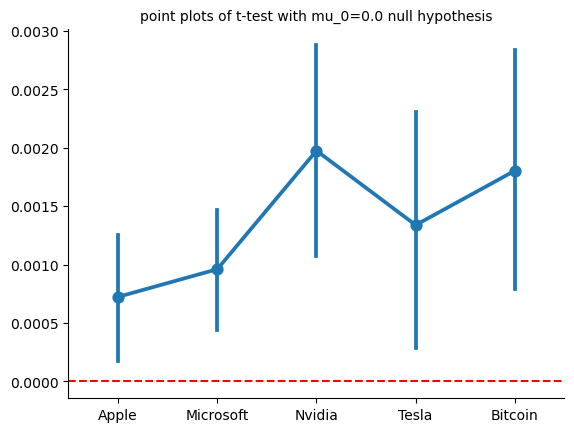

In [58]:
asset_1ttest_plots = plots_1ttest(asset_return_df, 0.0)

In [59]:
asset_return_2ttest_equal
asset_return_2ttest_greater
asset_return_2ttest_less


,T,dof,alternative,p_val,CI95,cohen_d,power
T_test,-2.2907,8416,less,0.0110,"[-inf, -0.0]",0.0499,0.7407
T_test,-1.8823,8416,less,0.0299,"[-inf, -0.0]",0.0410,0.5938
T_test,-1.7770,8416,less,0.0378,"[-inf, -0.0]",0.0387,0.5525
T_test,-1.4025,8416,less,0.0804,"[-inf, 0.0]",0.0306,0.4042
T_test,-1.0310,8416,less,0.1513,"[-inf, 0.0]",0.0225,0.2696
T_test,-0.8998,8416,less,0.1841,"[-inf, 0.0]",0.0196,0.2281
T_test,-0.6408,8416,less,0.2608,"[-inf, 0.0]",0.0140,0.1577
T_test,-0.6221,8416,less,0.2669,"[-inf, 0.0]",0.0136,0.1532
T_test,-0.6155,8416,less,0.2691,"[-inf, 0.0]",0.0134,0.1517
T_test,-0.2387,8416,less,0.4057,"[-inf, 0.0]",0.0052,0.0798


In [ ]:


# dataframe of sample return
sample_list_stratified = asset_return_stratified(asset_return_df, ticker='Apple')

# dataframe of sample descriptive statistics
sample_list_des_stats = sample_list_stratified.apply(sample_des_stats)

ticker='Apple'
mu_0 = asset_return_df[ticker].mean()
#print(mu_0)
# dataframe of 1-sample t-test for population mean
## welch test is needed as samples don't have the same size
sample_return_1ttest_equal = sample_list_stratified.apply(lambda x: asset_1ttest(x,mu_0,'two-sided','True'), axis=0) # 2-tail
sample_return_1ttest_greater = sample_list_stratified.apply(lambda x: asset_1ttest(x,mu_0,'greater','True'), axis=0) # 1-tail-right
sample_return_1ttest_less = sample_list_stratified.apply(lambda x: asset_1ttest(x,mu_0,'less','True'), axis=0) # 1-tail-left

# dataframe of 2-sample t-test for two means
## welch test is needed as samples don't have the same size
sample_return_2ttest_equal = asset_2ttest(sample_list_stratified, 'two-sided', 'True') # 2-tail
sample_return_2ttest_greater = asset_2ttest(sample_list_stratified, 'greater', 'True') # 1-tail-right
sample_return_2ttest_less = asset_2ttest(sample_list_stratified, 'less', 'True') # 1-tail-left

In [61]:
sample_list_stratified
sample_list_des_stats


,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
count,365.000000,366.000000,365.000000,365.000000,365.000000,366.000000,365.000000,365.000000,365.000000,366.000000
mean,0.000112,-0.000186,0.001158,0.001312,-0.001140,0.003513,0.000194,-0.000037,0.001690,0.001438
std,0.015374,0.016070,0.010190,0.014070,0.020081,0.028143,0.016856,0.020517,0.018017,0.013446
min,-0.061163,-0.065706,-0.038777,-0.043390,-0.099607,-0.128647,-0.056018,-0.058679,-0.048020,-0.048167
25%,-0.007969,-0.007652,-0.003605,-0.005029,-0.009836,-0.007540,-0.008425,-0.012692,-0.007547,-0.006856
50%,-0.000588,-0.000098,0.000952,0.000524,-0.000206,0.001697,0.000613,0.000000,0.001796,0.000726
75%,0.008638,0.007745,0.005938,0.008235,0.010355,0.014924,0.010157,0.014115,0.010119,0.007957
max,0.057355,0.064963,0.060981,0.058910,0.070421,0.119808,0.063521,0.069778,0.088975,0.072649
skewness,-0.291908,0.182579,0.132120,0.164085,-0.511302,0.438928,-0.129152,0.058218,0.657209,0.862409
kurtosis,2.529096,2.190626,5.821287,2.096086,2.582964,5.129416,1.291277,0.524529,3.398728,4.690262


In [62]:
sample_return_1ttest_equal
sample_return_1ttest_greater
sample_return_1ttest_less


,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
mu_null,0.000724,0.000724,0.000724,0.000724,0.000724,0.000724,0.000724,0.000724,0.000724,0.000724
mu_alternative,0.000112,-0.000186,0.001158,0.001312,-0.001140,0.003513,0.000194,-0.000037,0.001690,0.001438
T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dof,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alternative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
p_val,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CI95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cohen_d,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
power,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


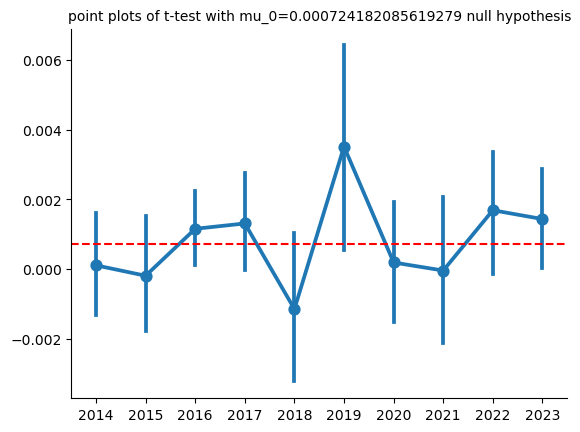

In [63]:
sample_1ttest_plots = plots_1ttest(sample_list_stratified, mu_0=mu_0)

In [64]:
sample_return_2ttest_equal
sample_return_2ttest_greater
sample_return_2ttest_less


,T,dof,alternative,p_val,CI95,cohen_d,power
T_test,-2.5723,729,less,0.0052,"[-inf, -0.0]",0.1903,0.8225
T_test,-2.1834,730,less,0.0147,"[-inf, -0.0]",0.1614,0.7042
T_test,-2.0395,729,less,0.0209,"[-inf, -0.0]",0.1509,0.6528
T_test,-2.0264,729,less,0.0215,"[-inf, -0.0]",0.1499,0.6479
T_test,-2.0039,728,less,0.0227,"[-inf, -0.0]",0.1483,0.6395
...,...,...,...,...,...,...,...
T_test,2.0039,728,less,0.9773,"[-inf, 0.01]",0.1483,0.0001
T_test,2.0264,729,less,0.9785,"[-inf, 0.01]",0.1499,0.0001
T_test,2.0395,729,less,0.9791,"[-inf, 0.0]",0.1509,0.0001
T_test,2.1834,730,less,0.9853,"[-inf, 0.01]",0.1614,0.0001
